# Database Analysis Notebook

Set a database path once, then run the three analysis sections:
1. Speed over time per vessel
2. First vs last timestamp per vessel
3. Loitering-style vessel cluster plots

In [8]:
from pathlib import Path
import sqlite3

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)


def load_all_positions(db_path: Path) -> pd.DataFrame:
    conn = sqlite3.connect(str(db_path))
    try:
        q = """
            SELECT
                mmsi,
                base_datetime,
                lat,
                lon,
                sog,
                cog,
                vessel_name
            FROM ais_positions
            ORDER BY mmsi, base_datetime
        """
        df = pd.read_sql_query(q, conn)
    finally:
        conn.close()

    # Handle mixed timestamp formats and timezone suffixes robustly.
    ts_text = df["base_datetime"].astype(str).str.strip()
    ts_text = ts_text.str.replace("Z", "+00:00", regex=False)
    df["base_datetime"] = pd.to_datetime(ts_text, errors="coerce", utc=True).dt.tz_localize(None)
    df["sog"] = pd.to_numeric(df["sog"], errors="coerce")
    df["lat"] = pd.to_numeric(df["lat"], errors="coerce")
    df["lon"] = pd.to_numeric(df["lon"], errors="coerce")
    return df

In [9]:
# normal
# DB_PATH = Path("/home/isaacp/repos/directlabs/JFN-Groundtruth-Simulator/actint/data/db/ais.db")
# disappearance
DB_PATH = Path("/home/isaacp/repos/direct/Actint/data/db/anomalies/disappearance/ais_disappearance.db")
# loitering
# DB_PATH = Path("/home/isaacp/repos/direct/Actint/data/db/anomalies/loitering/ais_loitering.db")
# speeding
# DB_PATH = Path("/home/isaacp/repos/direct/Actint/data/db/anomalies/speeding/ais_speeding.db")


In [10]:
# Set this to the database you want to analyze.

if not DB_PATH.exists():
    raise FileNotFoundError(f"Database not found: {DB_PATH}")

df = load_all_positions(DB_PATH)
if df.empty:
    raise ValueError("No rows found in ais_positions.")

mmsis = sorted(df["mmsi"].dropna().astype(int).unique().tolist())
print(f"Loaded {len(df):,} AIS rows from {DB_PATH}")
print(f"Found {len(mmsis)} vessels")

df.head()

Loaded 10,226 AIS rows from /home/isaacp/repos/direct/Actint/data/db/anomalies/disappearance/ais_disappearance.db
Found 15 vessels


,mmsi,base_datetime,lat,lon,sog,cog,vessel_name
0,338812000,2023-01-01 00:00:08,30.39729,-81.41473,0.0,281.2,USS LASSEN
1,338812000,2023-01-01 00:01:27,30.39723,-81.41480,0.1,83.8,USS LASSEN
2,338812000,2023-01-01 00:03:08,30.39733,-81.41455,0.0,142.3,USS LASSEN
3,338812000,2023-01-01 00:04:27,30.39728,-81.41476,0.1,87.6,USS LASSEN
4,338812000,2023-01-01 00:06:07,30.39733,-81.41460,0.1,118.0,USS LASSEN


In [11]:
df[df["mmsi"] == 338951000]

,mmsi,base_datetime,lat,lon,sog,cog,vessel_name
2565,338951000,2023-01-01 00:00:01.000000,32.650930,-117.253806,11.339544,242.394599,USS LAKE CHAMPLAIN
2566,338951000,2023-01-01 00:00:52.677166,32.649509,-117.256737,11.903379,240.067182,USS LAKE CHAMPLAIN
2567,338951000,2023-01-01 00:01:43.844056,32.648090,-117.259753,12.279637,240.819353,USS LAKE CHAMPLAIN
2568,338951000,2023-01-01 00:02:53.756237,32.646346,-117.263881,12.015047,243.347543,USS LAKE CHAMPLAIN
2569,338951000,2023-01-01 00:04:03.181221,32.644391,-117.267768,11.861407,239.144912,USS LAKE CHAMPLAIN
...,...,...,...,...,...,...,...
2951,338951000,2023-01-01 06:23:09.248505,32.025647,-118.570639,12.140948,240.324191,USS LAKE CHAMPLAIN
2952,338951000,2023-01-01 06:24:15.478369,32.023859,-118.574528,12.234354,241.522407,USS LAKE CHAMPLAIN
2953,338951000,2023-01-01 06:25:08.820088,32.022349,-118.577382,11.547500,238.031132,USS LAKE CHAMPLAIN
2954,338951000,2023-01-01 06:25:59.021424,32.021063,-118.580391,12.294012,243.254921,USS LAKE CHAMPLAIN


## 1) Speed Over Time Per Vessel

x-axis: timestamp, y-axis: SOG (knots), one panel per vessel.

Speed plot index -> MMSI
1: 338812000
2: 338839000
3: 338847000
4: 338951000
5: 366984000
6: 366998000
7: 368011000
8: 368702000
9: 368869000
10: 368988000
11: 369970707
12: 369970709
13: 369970719
14: 369970910
15: 369970968


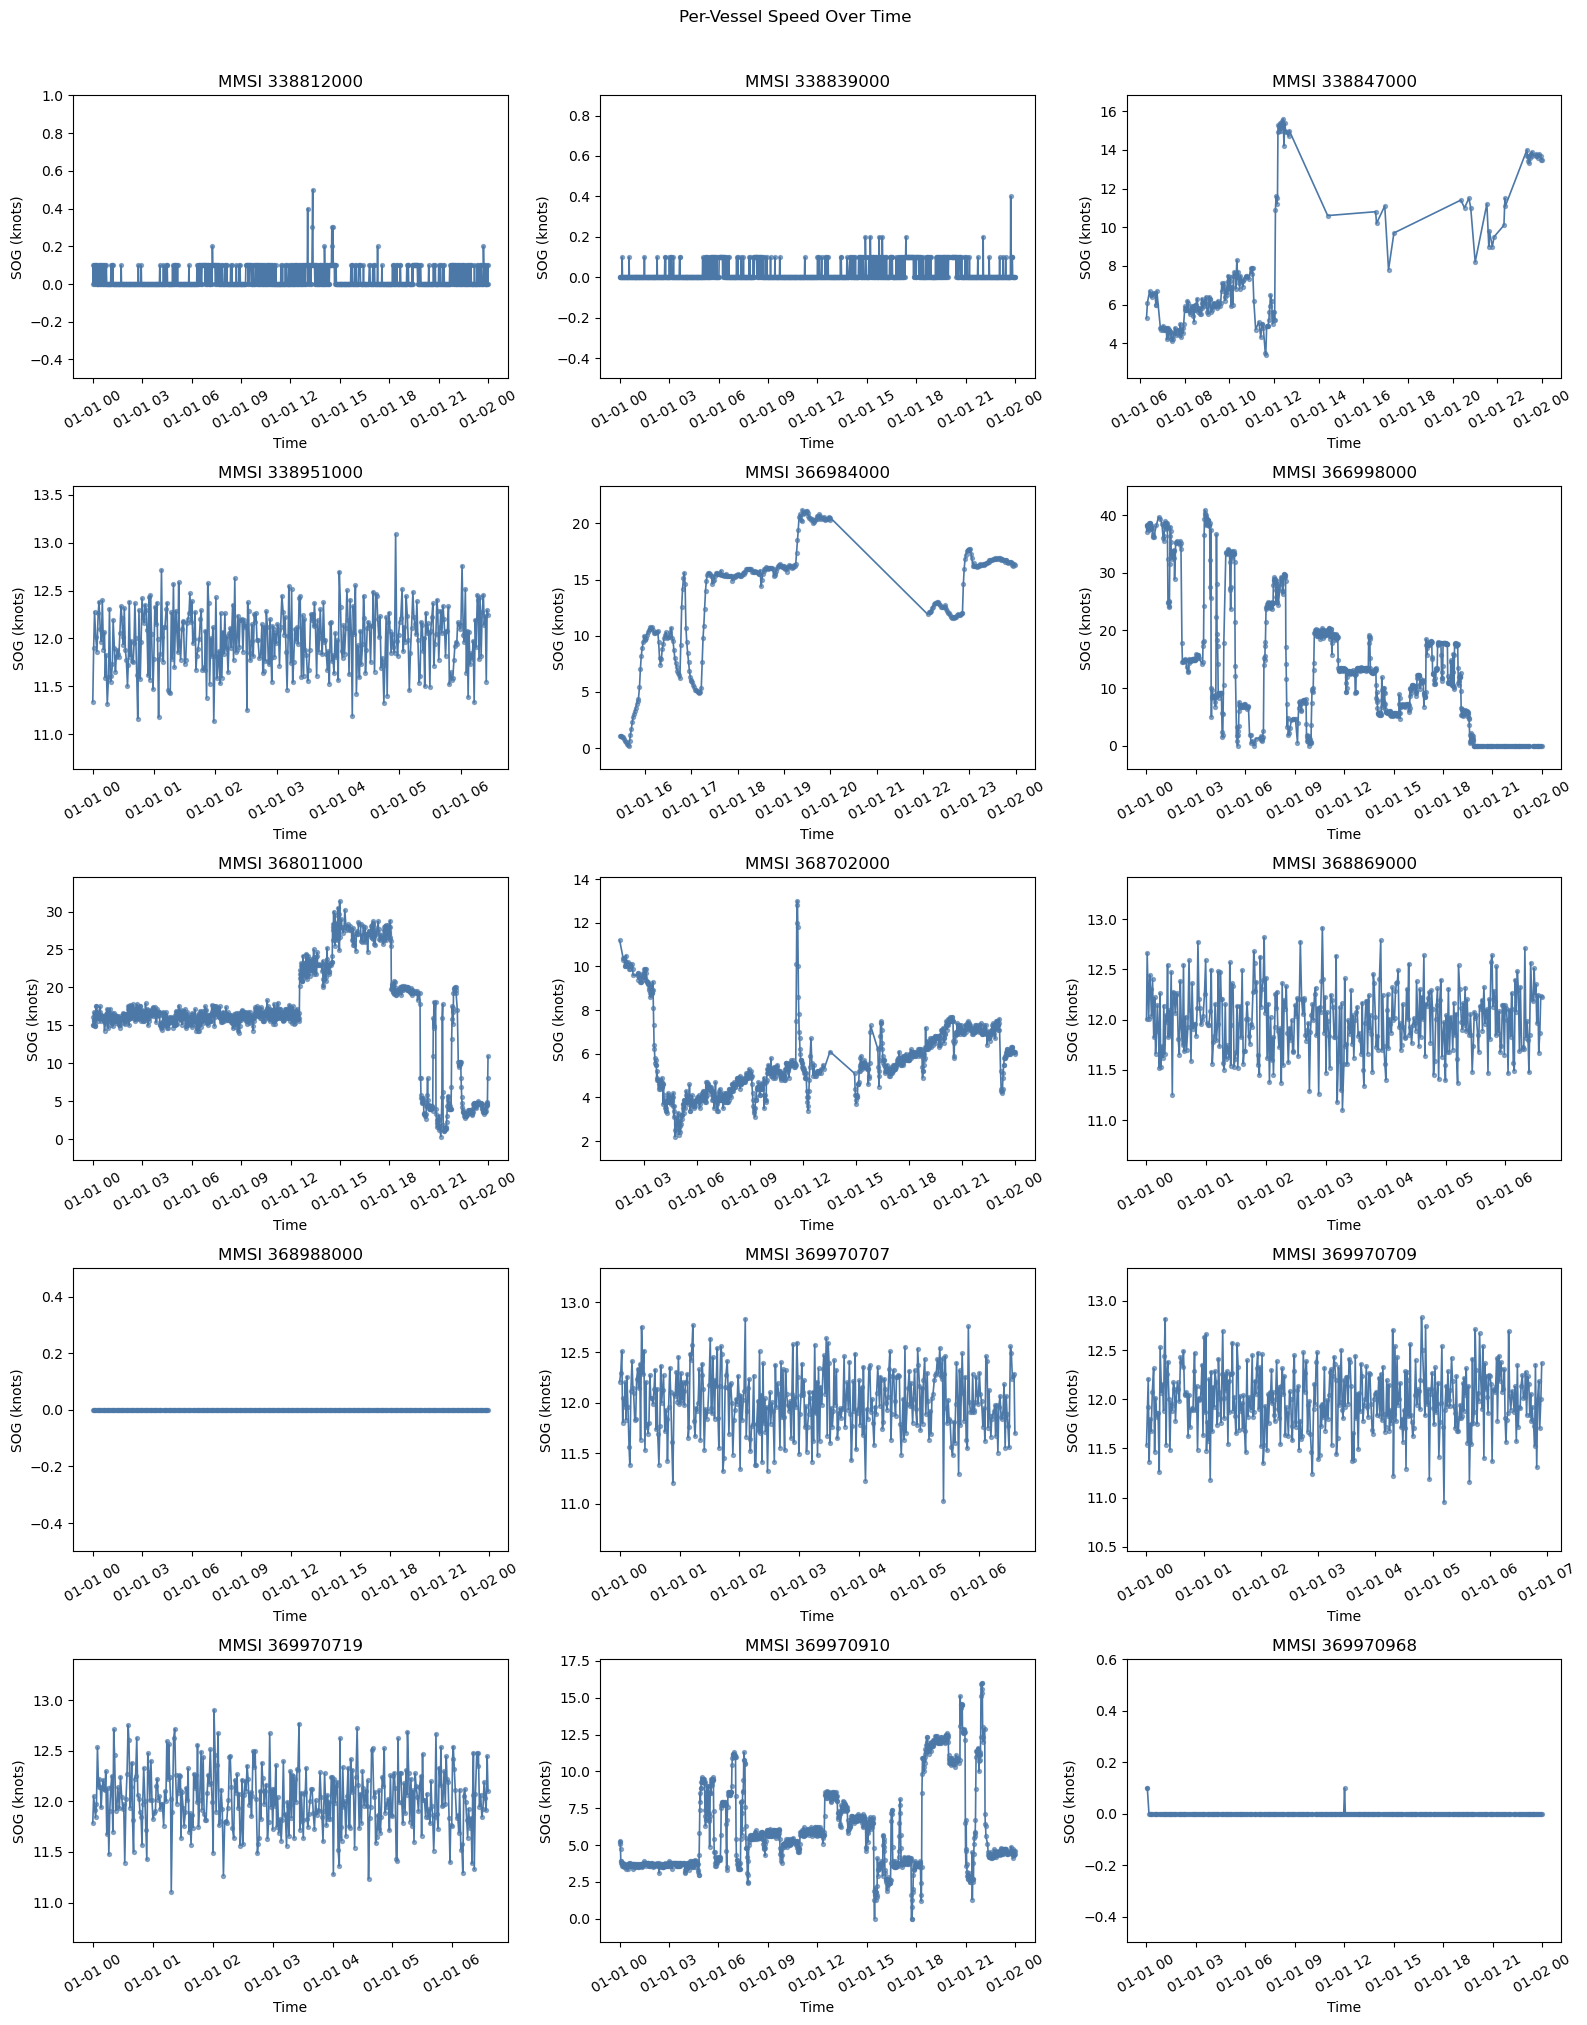

In [12]:
plot_df = df.dropna(subset=["base_datetime", "sog", "mmsi"]).copy()
plot_df["mmsi"] = plot_df["mmsi"].astype(int)

if plot_df.empty:
    print("No valid time/speed rows to plot.")
else:
    all_mmsis = sorted(plot_df["mmsi"].unique().tolist())
    print("Speed plot index -> MMSI")
    for plot_idx, mmsi in enumerate(all_mmsis, start=1):
        print(f"{plot_idx}: {mmsi}")

    n = len(all_mmsis)
    ncols = 3
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows), sharex=False, sharey=False)
    axes = np.atleast_1d(axes).ravel()

    for i, mmsi in enumerate(all_mmsis):
        ax = axes[i]
        vessel = plot_df[plot_df["mmsi"] == mmsi].sort_values("base_datetime")

        ax.plot(vessel["base_datetime"], vessel["sog"], color="#4c78a8", linewidth=1.2)
        ax.scatter(vessel["base_datetime"], vessel["sog"], color="#4c78a8", s=8, alpha=0.6)

        sog_min, sog_max = vessel["sog"].min(), vessel["sog"].max()
        sog_span = sog_max - sog_min
        sog_pad = max(sog_span * 0.1, 0.5)
        ax.set_ylim(sog_min - sog_pad, sog_max + sog_pad)

        ax.set_title(f"MMSI {mmsi}")
        ax.set_xlabel("Time")
        ax.set_ylabel("SOG (knots)")
        ax.tick_params(axis="x", labelrotation=30)

    for j in range(n, len(axes)):
        axes[j].axis("off")

    fig.suptitle("Per-Vessel Speed Over Time", y=1.01)
    plt.tight_layout()
    plt.show()

## 2) First vs Last Timestamp Per Vessel

Single horizontal timeline showing vessel reporting span.

Timeline index -> MMSI
1: 338951000
2: 368011000
3: 368869000
4: 369970707
5: 369970709
6: 369970719
7: 369970910
8: 338839000
9: 368988000
10: 338812000
11: 366998000
12: 369970968
13: 368702000
14: 338847000
15: 366984000


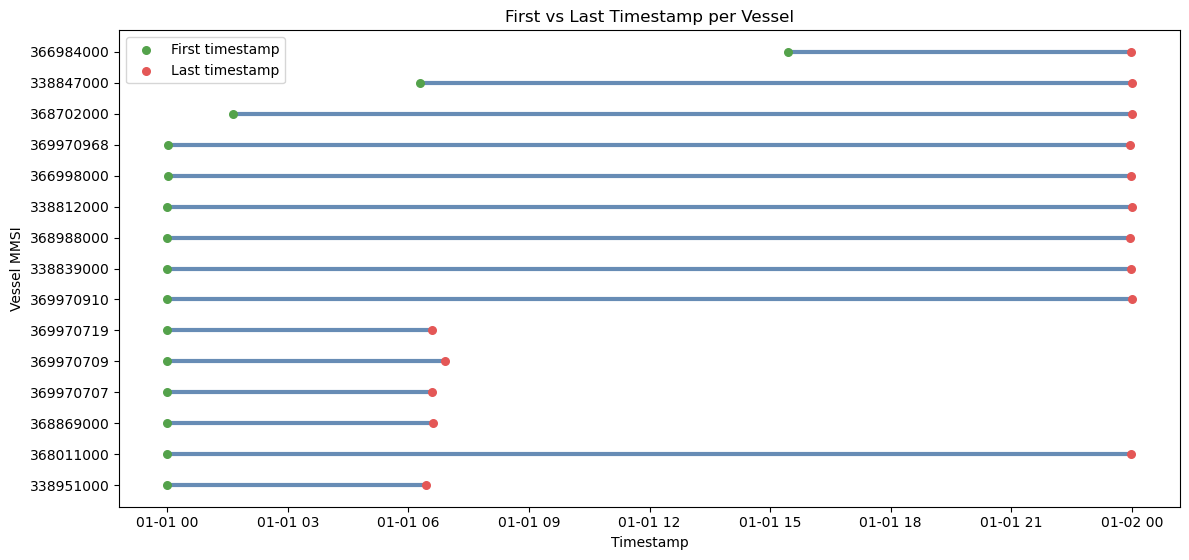

In [13]:
span_df = df.dropna(subset=["base_datetime", "mmsi"]).copy()
span_df["mmsi"] = span_df["mmsi"].astype(int)

if span_df.empty:
    print("No valid timestamp rows to plot.")
else:
    vessel_span = (
        span_df.groupby("mmsi")["base_datetime"]
        .agg(first_ts="min", last_ts="max")
        .reset_index()
        .sort_values("first_ts")
        .reset_index(drop=True)
    )

    print("Timeline index -> MMSI")
    for plot_idx, mmsi in enumerate(vessel_span["mmsi"].astype(int).tolist(), start=1):
        print(f"{plot_idx}: {mmsi}")

    y = np.arange(len(vessel_span))

    fig, ax = plt.subplots(figsize=(12, max(5, 0.38 * len(vessel_span))))
    ax.hlines(
        y=y,
        xmin=vessel_span["first_ts"],
        xmax=vessel_span["last_ts"],
        color="#4c78a8",
        linewidth=3,
        alpha=0.85,
    )
    ax.scatter(vessel_span["first_ts"], y, color="#54a24b", s=30, label="First timestamp", zorder=3)
    ax.scatter(vessel_span["last_ts"], y, color="#e45756", s=30, label="Last timestamp", zorder=3)

    ax.set_yticks(y)
    ax.set_yticklabels(vessel_span["mmsi"].astype(str))
    ax.set_xlabel("Timestamp")
    ax.set_ylabel("Vessel MMSI")
    ax.set_title("First vs Last Timestamp per Vessel")
    ax.legend()
    plt.tight_layout()
    plt.show()

## 3) Loitering-Style Cluster Plot Per Vessel

Longitude/latitude scatter by vessel, auto-scaled to each vessel track breadth.

Cluster plot index -> MMSI
1: 338812000
2: 338839000
3: 338847000
4: 338951000
5: 366984000
6: 366998000
7: 368011000
8: 368702000
9: 368869000
10: 368988000
11: 369970707
12: 369970709
13: 369970719
14: 369970910
15: 369970968


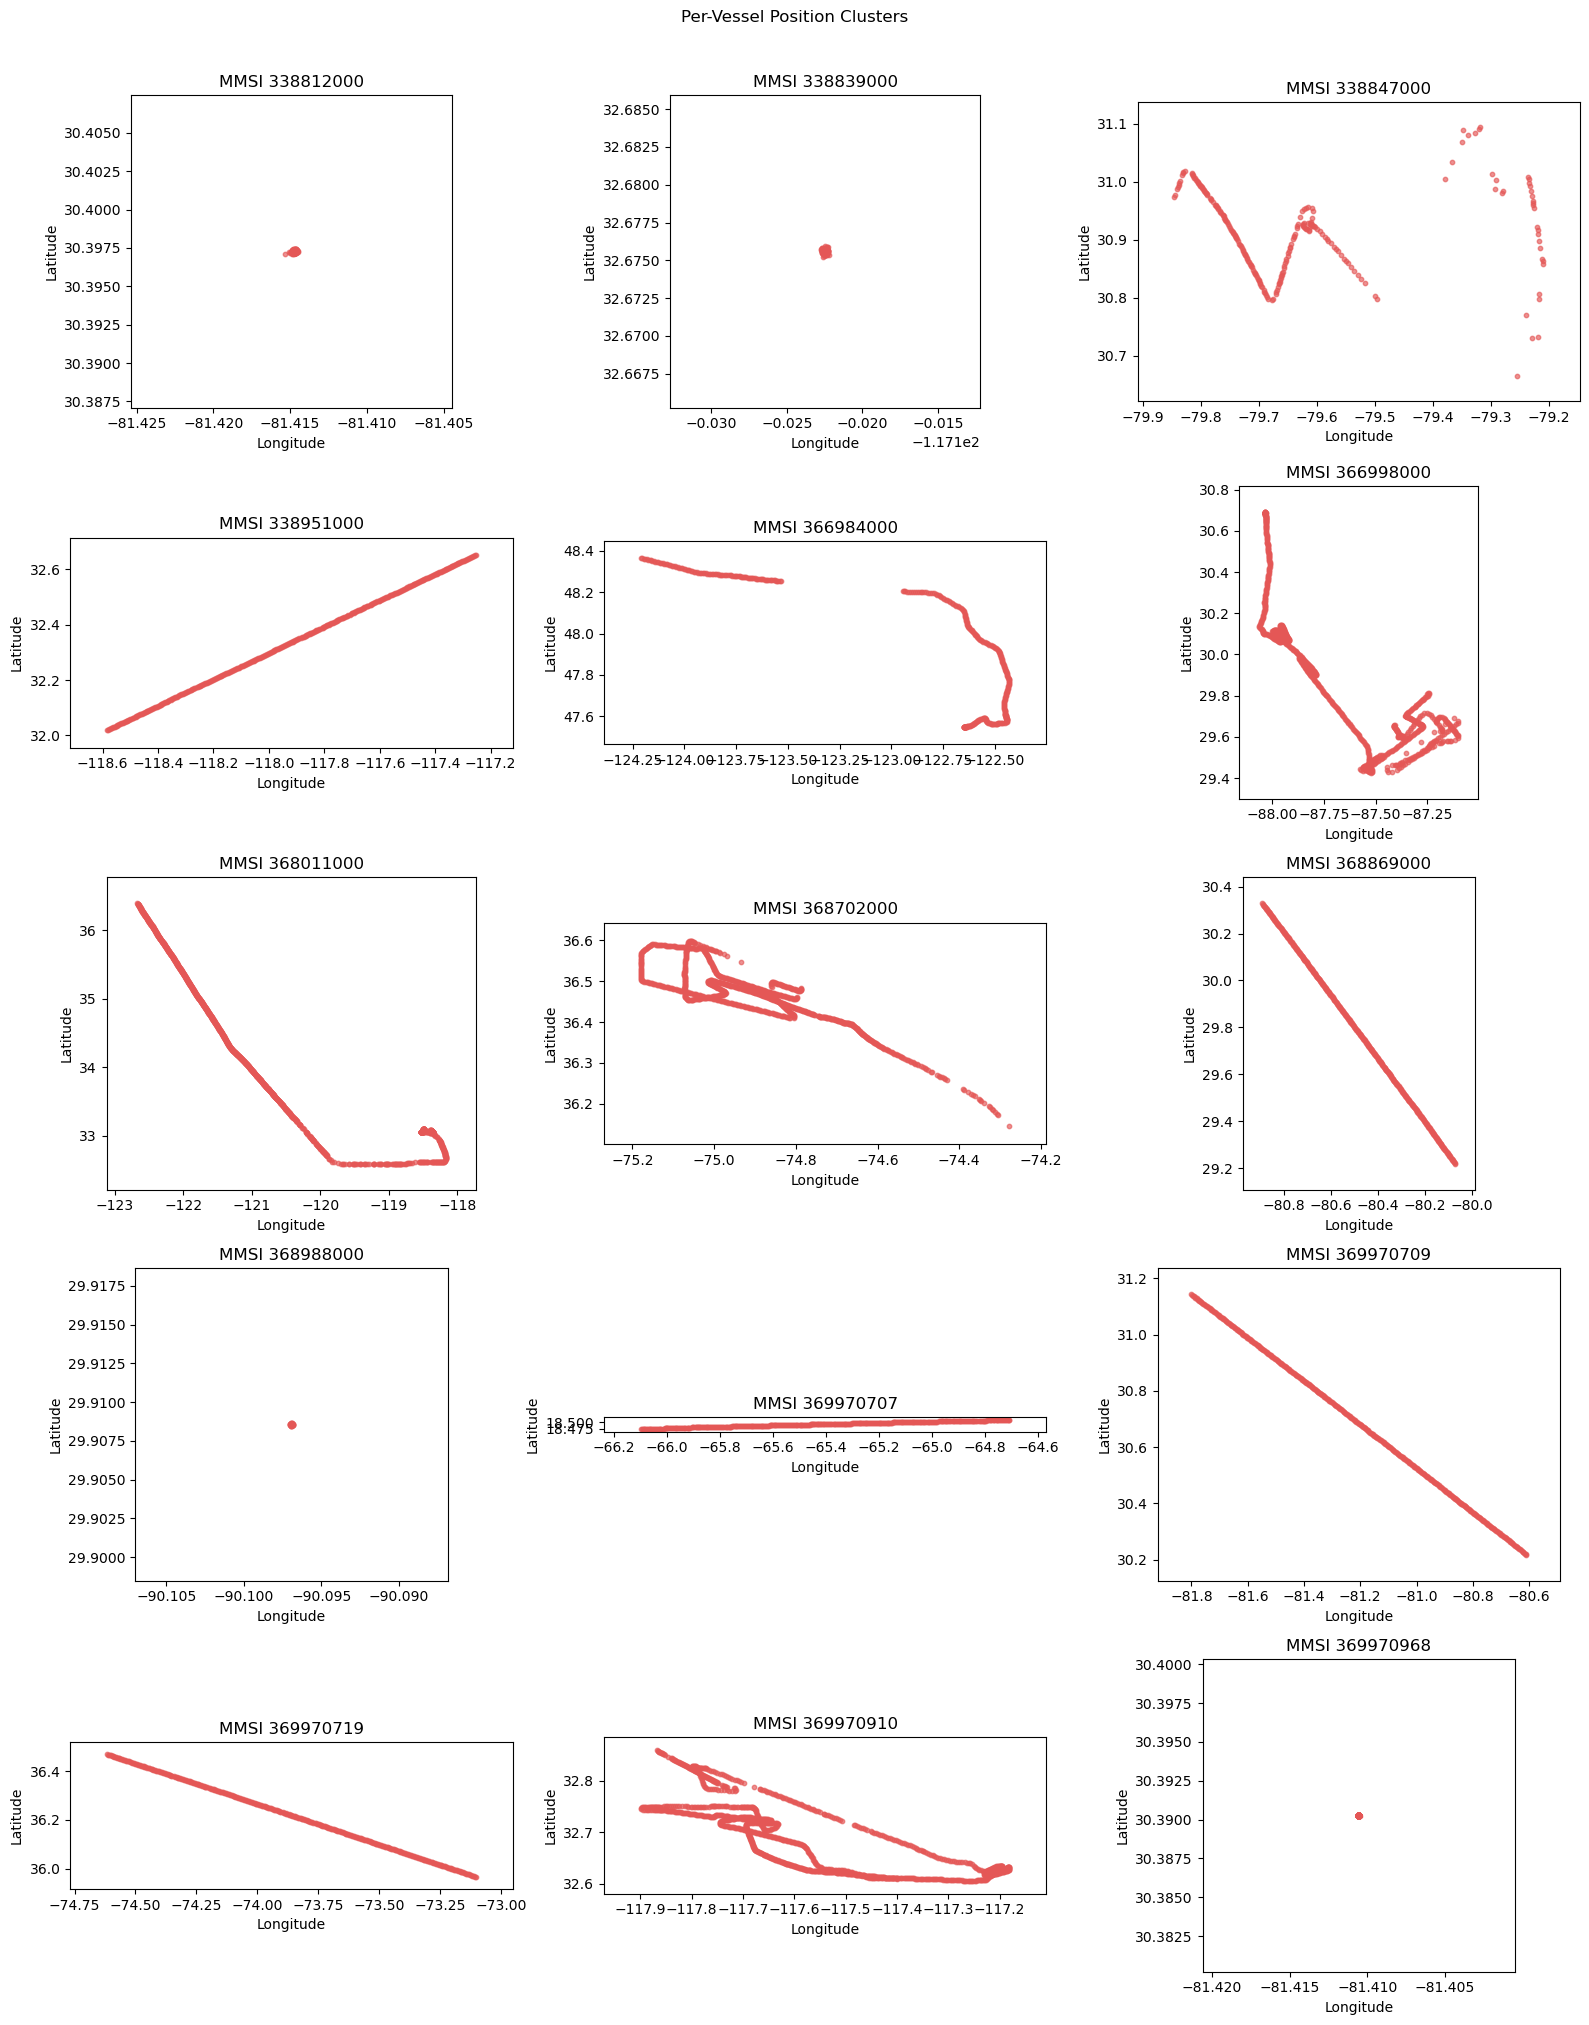

In [14]:
cluster_df = df.dropna(subset=["lon", "lat", "mmsi"]).copy()
cluster_df["mmsi"] = cluster_df["mmsi"].astype(int)

if cluster_df.empty:
    print("No valid position rows to plot.")
else:
    all_mmsis = sorted(cluster_df["mmsi"].unique().tolist())
    print("Cluster plot index -> MMSI")
    for plot_idx, mmsi in enumerate(all_mmsis, start=1):
        print(f"{plot_idx}: {mmsi}")

    n = len(all_mmsis)
    ncols = 3
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows), sharex=False, sharey=False)
    axes = np.atleast_1d(axes).ravel()

    for i, mmsi in enumerate(all_mmsis):
        ax = axes[i]
        vessel = cluster_df[cluster_df["mmsi"] == mmsi]

        ax.scatter(vessel["lon"], vessel["lat"], s=10, alpha=0.65, color="#e45756")

        lon_min, lon_max = vessel["lon"].min(), vessel["lon"].max()
        lat_min, lat_max = vessel["lat"].min(), vessel["lat"].max()
        lon_span = lon_max - lon_min
        lat_span = lat_max - lat_min
        lon_pad = max(lon_span * 0.1, 0.01)
        lat_pad = max(lat_span * 0.1, 0.01)

        ax.set_xlim(lon_min - lon_pad, lon_max + lon_pad)
        ax.set_ylim(lat_min - lat_pad, lat_max + lat_pad)
        ax.set_aspect("equal", adjustable="box")

        ax.set_title(f"MMSI {mmsi}")
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")

    for j in range(n, len(axes)):
        axes[j].axis("off")

    fig.suptitle("Per-Vessel Position Clusters", y=1.01)
    plt.tight_layout()
    plt.show()